In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from PIL import Image
from IPython.display import display
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from scipy.stats import pearsonr, spearmanr
from statsmodels.nonparametric.smoothers_lowess import lowess

plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 26,
    "axes.titlesize": 28,
    "axes.labelsize": 26,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 23,
})

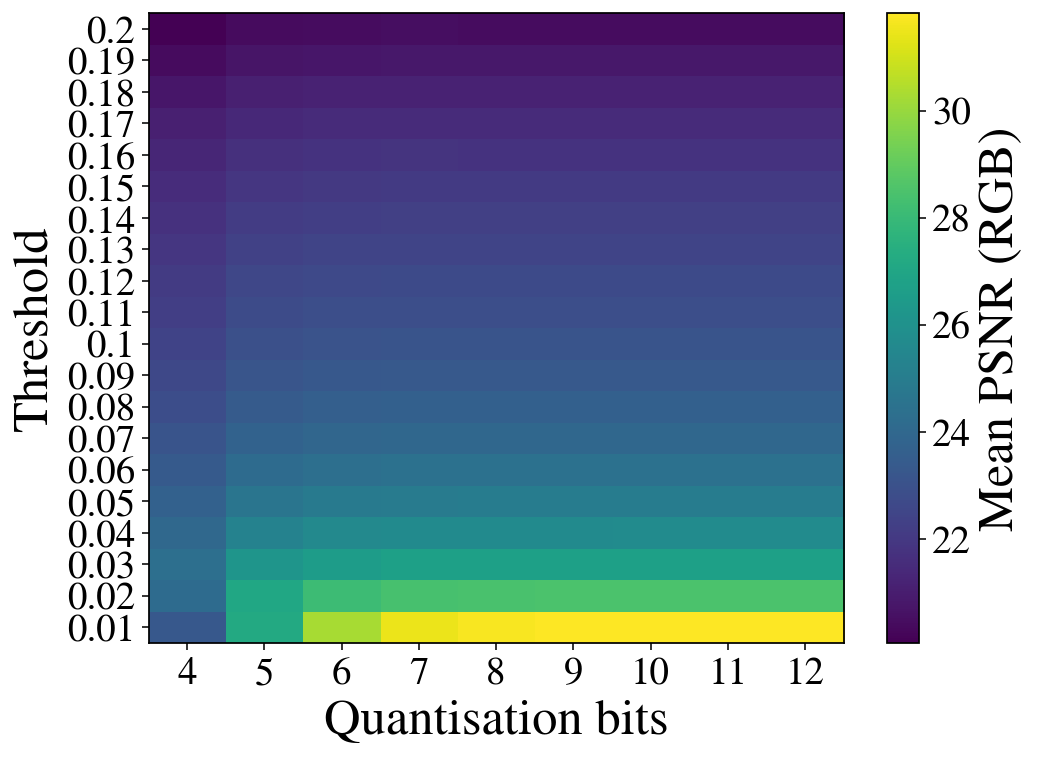

In [ ]:

df = pd.read_csv("/Users/jobryen/Documents/GitHub/essaycompressor/compress_test.tmp/sweep_in_memory_IMG_5138_20260319_211827.csv")
df = df[df["y_thresh"] != 0]

df["threshold"] = df["y_thresh"]
df["quant"] = df["y_quant"]

chosen_wavelet = "bior4.4"
chosen_level = 4
chosen_chroma = "04:02:00"

sub = df[
    (df["wavelet"] == chosen_wavelet) &
    (df["levels"] == chosen_level) &
    (df["chromasub"] == chosen_chroma)
]

heat = sub.pivot_table(
    index="threshold",
    columns="quant",
    values="psnr_rgb",
    aggfunc="mean"
)

plt.figure(figsize=(8, 6))
img = plt.imshow(heat.sort_index(), aspect="auto", origin="lower")
plt.colorbar(img, label="Mean PSNR (RGB)")
plt.xticks(range(len(heat.columns)), heat.columns)
plt.yticks(range(len(heat.index)), sorted(heat.index))
plt.xlabel("Quantisation bits")
plt.ylabel("Threshold")
plt.tight_layout()
plt.show()

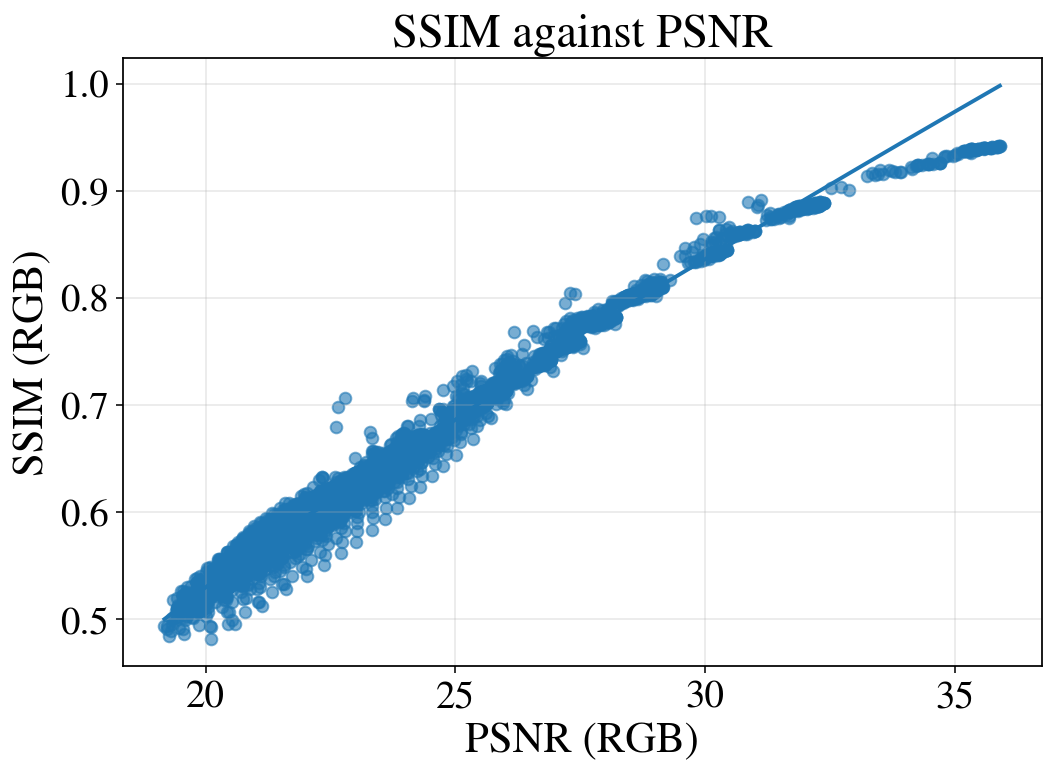

Pearson correlation: 0.9902 (p = 0.000e+00)
Spearman correlation: 0.9851 (p = 0.000e+00)


In [ ]:
plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 22,
    "axes.titlesize": 24,
    "axes.labelsize": 22,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 19,
})

x_col = "psnr_rgb"
y_col = "ssim_rgb"
required_cols = [x_col, y_col]
missing = [col for col in required_cols if col not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df[[x_col, y_col]].dropna().copy()
df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
df[y_col] = pd.to_numeric(df[y_col], errors="coerce")
df = df.dropna()

x = df[x_col].to_numpy()
y = df[y_col].to_numpy()


pearson_r, pearson_p = pearsonr(x, y)
spearman_rho, spearman_p = spearmanr(x, y)

order = np.argsort(x)
x_sorted = x[order]
y_sorted = y[order]
smooth = lowess(y_sorted, x_sorted, frac=0.45, return_sorted=True)


plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.6)
plt.plot(smooth[:, 0], smooth[:, 1], linewidth=2)

plt.xlabel("PSNR (RGB)")
plt.ylabel("SSIM (RGB)")
plt.title("SSIM against PSNR")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Pearson correlation: {pearson_r:.4f} (p = {pearson_p:.3e})")
print(f"Spearman correlation: {spearman_rho:.4f} (p = {spearman_p:.3e})")


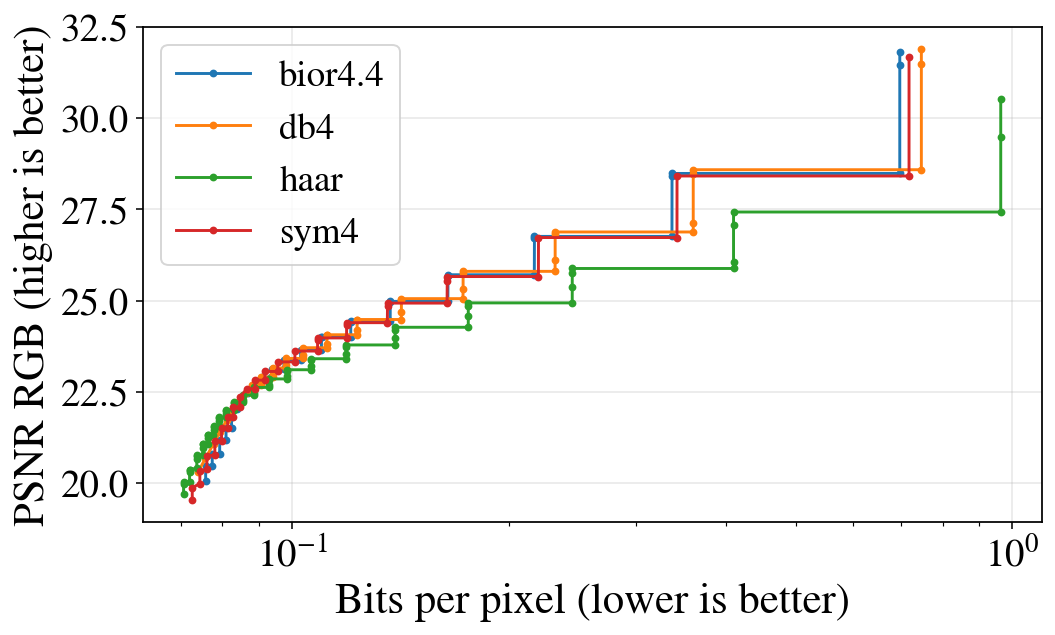

In [ ]:
df = pd.read_csv("/Users/jobryen/Documents/GitHub/essaycompressor/compress_test.tmp/sweep_in_memory_IMG_5138_20260319_211827.csv")

df["chromasub"] = df["chromasub"].replace({
    "04:02:00": "4:2:0",
    "04:02:02": "4:2:2",
    "04:04:04": "4:4:4"
})

max_bpp = 1.0
df = df[df["bits_per_pixel"] <= max_bpp].copy()

subset = df[(df["levels"] == 4) & (df["chromasub"] == "4:2:0")].copy()

def pareto_frontier(g, x="bits_per_pixel", y="psnr_rgb"):
    g = g[[x, y]].sort_values([x, y], ascending=[True, False])
    g = g.groupby(x, as_index=False)[y].max().sort_values(x)

    g[y] = g[y].cummax()

    keep = [True]
    yy = g[y].to_list()
    for i in range(1, len(g) - 1):
        keep.append(not (yy[i] == yy[i-1] and yy[i] == yy[i+1]))
    if len(g) > 1:
        keep.append(True)

    return g.loc[keep]

plt.figure(figsize=(8, 5))

for wavelet, g in subset.groupby("wavelet"):
    frontier = pareto_frontier(g, x="bits_per_pixel", y="psnr_rgb")
    plt.plot(frontier["bits_per_pixel"], frontier["psnr_rgb"],
             marker="o", markersize=3, label=wavelet)

plt.xscale("log")
plt.xlabel("Bits per pixel (lower is better)")
plt.ylabel("PSNR RGB (higher is better)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

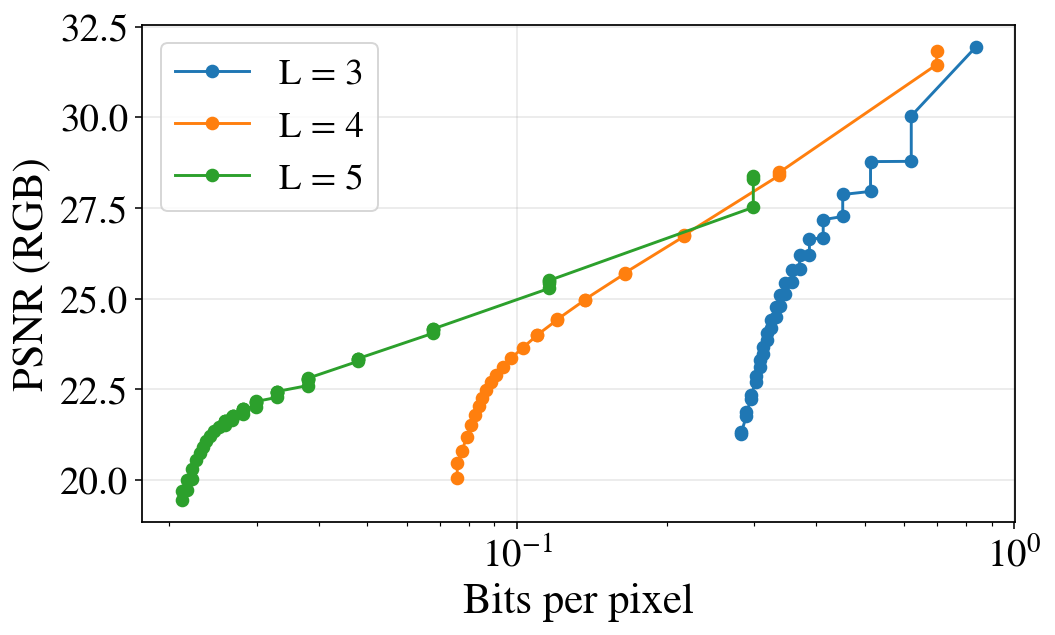

In [ ]:
df = pd.read_csv("/Users/jobryen/Documents/GitHub/essaycompressor/compress_test.tmp/sweep_in_memory_IMG_5138_20260319_211827.csv")
df = df[df["wavelet"] == "bior4.4"].copy()


max_bpp = 1.0
df = df[df["bits_per_pixel"] <= max_bpp].copy()

target_chroma = "04:02:00"  
df = df[df["chromasub"] == target_chroma].copy()

def pareto_frontier(g, x="bits_per_pixel", y="psnr_rgb"):
    g = g[[x, y]].dropna().sort_values([x, y], ascending=[True, False])
    best_y = -np.inf
    pts = []
    for xv, yv in g.to_numpy():
        if yv > best_y:
            pts.append((xv, yv))
            best_y = yv
    return pd.DataFrame(pts, columns=[x, y])

plt.figure(figsize=(8, 5))

for L in [3, 4, 5]:
    g = df[df["levels"] == L]
    f = pareto_frontier(g)
    plt.plot(f["bits_per_pixel"], f["psnr_rgb"], marker="o", label=f"L = {L}")

plt.xscale("log")
plt.xlabel("Bits per pixel")
plt.ylabel("PSNR (RGB)")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
ORIGINAL_PATH = "/Users/jobryen/Documents/GitHub/essaycompressor/compress_test.tmp/IMG_5138.tiff" 
IMAGE_PATHS = [
    "/Users/jobryen/Documents/GitHub/essaycompressor/example image/imgjpeg.jpg",
    "/Users/jobryen/Documents/GitHub/essaycompressor/example image/imgjob.jp2",
    "/Users/jobryen/Documents/GitHub/essaycompressor/example image/imgjpeg2000.jp2",
]
IMAGE_LABELS = [
    "JPEG",
    "JOB",
    "JPEG2000",
]

MANUAL_CROPS = [
    (2028,1520,2380,1872),
    (2400,1252,2664,1516),
    (996,512,1288,804),
]

MANUAL_FILE_SIZES = {
    "JPEG": None,
    "JOB": 1063492,
    "JPEG2000": None,
}


In [ ]:
def load_rgb(path):
    path = str(path)
    arr = np.array(Image.open(path).convert("RGB"))
    return arr.astype(np.uint8)


def image_metrics(ref, test, original_path, test_path, manual_size_bytes=None):

    psnr_rgb = peak_signal_noise_ratio(ref, test, data_range=255)
    ssim_rgb = structural_similarity(ref, test, channel_axis=2, data_range=255)

    h, w = ref.shape[:2]

    if manual_size_bytes is None:
        test_size = Path(test_path).stat().st_size
    else:
        test_size = manual_size_bytes

    orig_size = Path(original_path).stat().st_size

    bits_per_pixel = 8 * test_size / (h * w)
    compression_ratio = orig_size / test_size

    return {
        "file": Path(test_path).name,
        "size_bytes": test_size,
        "bits_per_pixel": bits_per_pixel,
        "compression_ratio": compression_ratio,
        "psnr_rgb": psnr_rgb,
        "ssim_rgb": ssim_rgb,
    }

def crop_image(image, box):
    x0, y0, x1, y1 = box
    return image[y0:y1, x0:x1]


def show_crop_locations(image, boxes, save_path):
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(image)

    for i, (x0, y0, x1, y1) in enumerate(boxes, start=1):
        rect = plt.Rectangle(
            (x0, y0),
            x1 - x0,
            y1 - y0,
            fill=False,
            edgecolor="red",
            linewidth=1.5
        )
        ax.add_patch(rect)

        ax.text(
            x0 + 8,
            y0 - 8 if y0 > 30 else y0 + 8,
            f"{i}",
            color="red",
            fontsize=16,
            fontweight="bold",
            bbox=dict(
                facecolor="white",
                edgecolor="red",
                linewidth=1.2,
                boxstyle="square,pad=0.15"
            )
        )

    ax.axis("off")
    plt.tight_layout()
    fig.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight",
        pil_kwargs={"quality": 95, "subsampling": 0, "optimize": True}
    )

    plt.show()

,label,file,size_bytes,bits_per_pixel,compression_ratio,psnr_rgb,ssim_rgb
0,JPEG,imgjpeg.jpg,1079959,0.709,33.87,38.60,0.9747
1,JOB,imgjob.jp2,1063492,0.698,34.40,31.45,0.8784
2,JPEG2000,imgjpeg2000.jp2,1006627,0.660,36.34,40.25,0.9804


Crop boxes: [(2028, 1520, 2380, 1872), (2400, 1252, 2664, 1516), (996, 512, 1288, 804)]


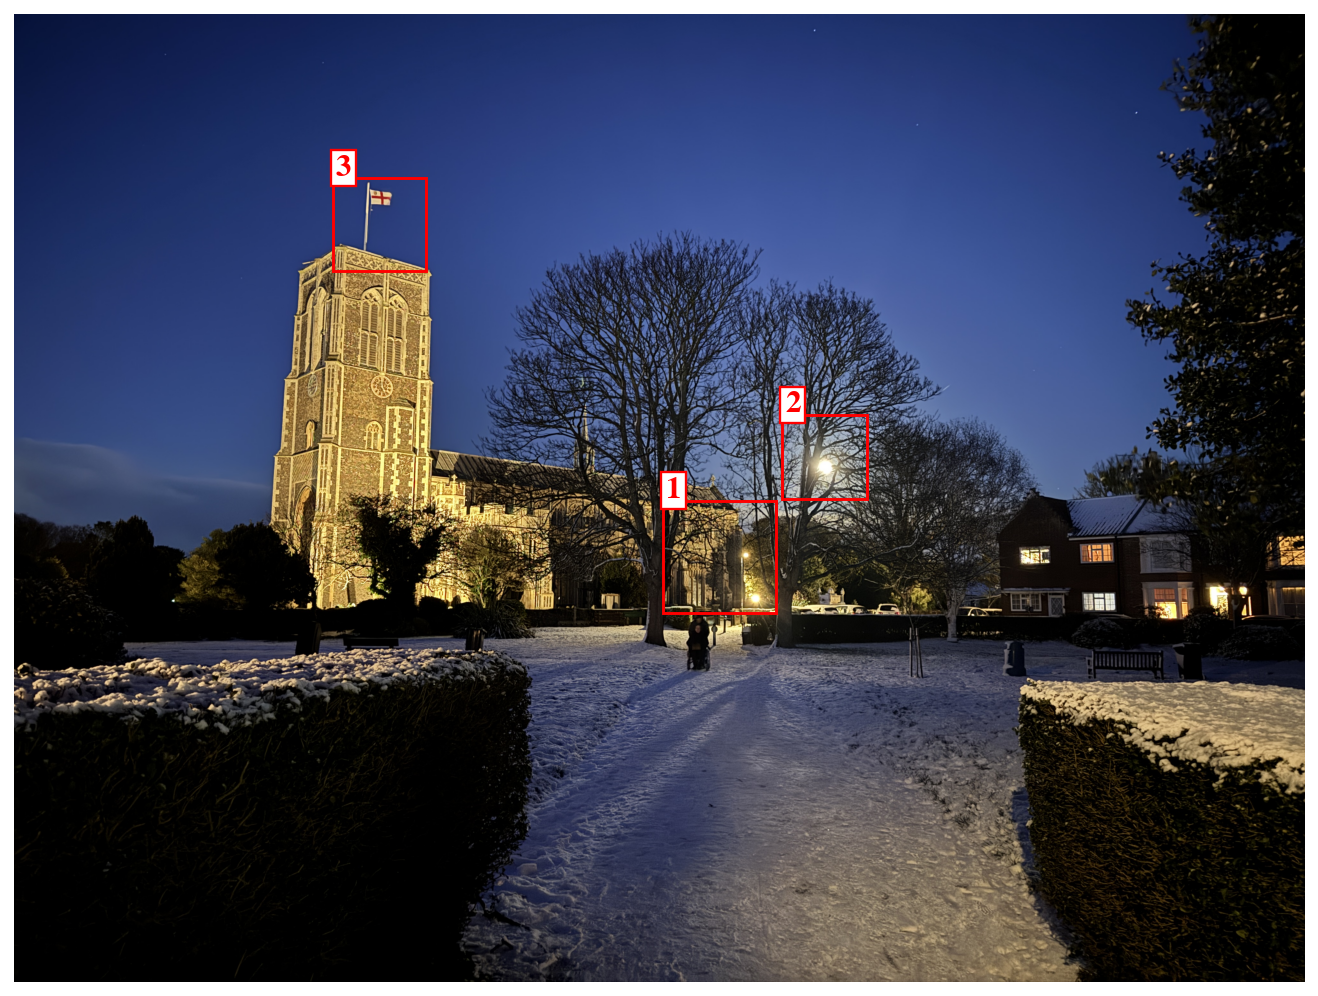

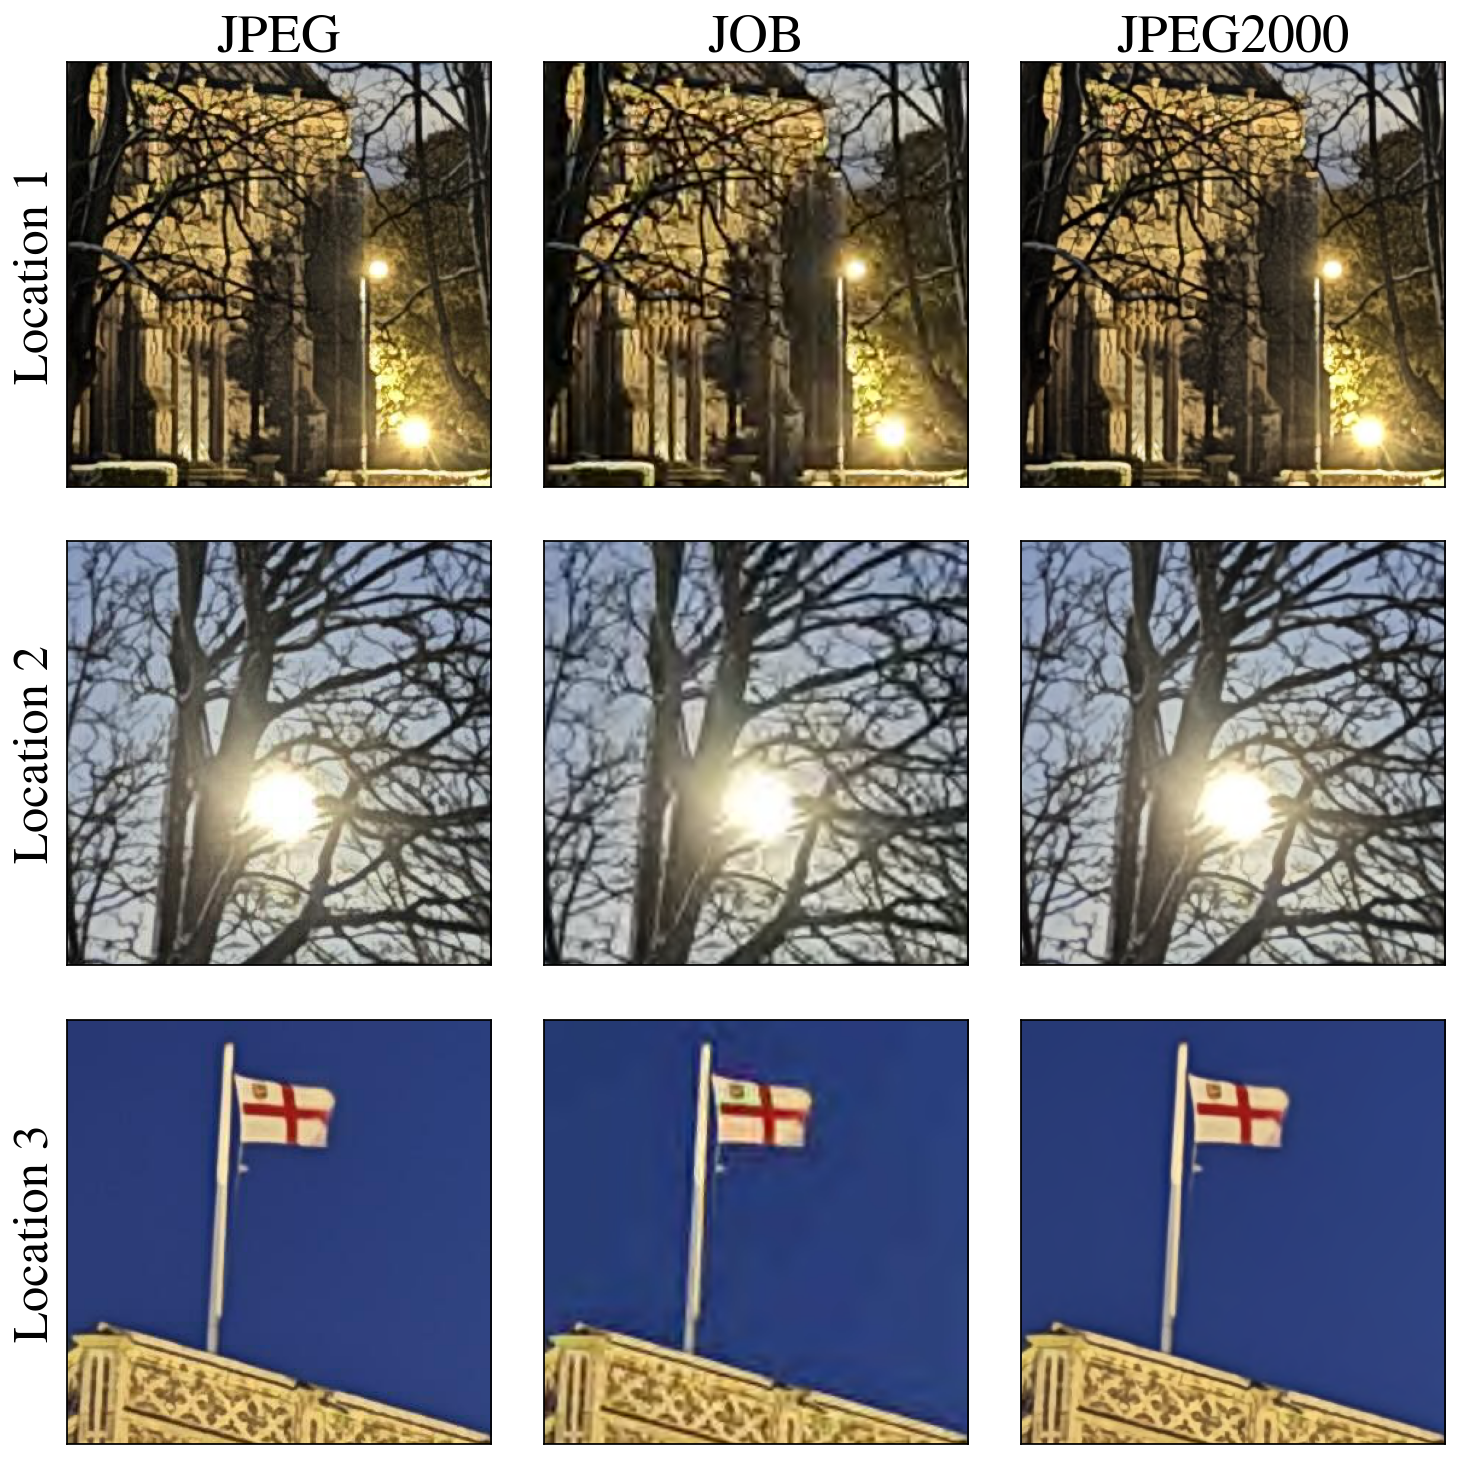

In [ ]:
plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 26,
    "axes.titlesize": 28,
    "axes.labelsize": 26,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 23,
})



original = load_rgb(ORIGINAL_PATH)
compressed = [load_rgb(p) for p in IMAGE_PATHS]

all_images = [original] + compressed
original = all_images[0]
compressed = all_images[1:]

rows = []
for path, label, img in zip(IMAGE_PATHS, IMAGE_LABELS, compressed):
    row = image_metrics(
        original,
        img,
        ORIGINAL_PATH,
        path,
        manual_size_bytes=MANUAL_FILE_SIZES[label]
    )
    row["label"] = label
    rows.append(row)

metrics_df = pd.DataFrame(rows)[[
    "label", "file", "size_bytes", "bits_per_pixel", "compression_ratio",
    "psnr_rgb", "ssim_rgb",
]]

display(metrics_df.style.format({
    "bits_per_pixel": "{:.3f}",
    "compression_ratio": "{:.2f}",
    "psnr_rgb": "{:.2f}",
    "ssim_rgb": "{:.4f}",
}))

crop_boxes = MANUAL_CROPS

print("Crop boxes:", crop_boxes)

show_crop_locations(
    original,
    crop_boxes,
    save_path="/Users/jobryen/Downloads/comparison_boxes_highres.jpg"
)

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(11, 11))

for r, box in enumerate(crop_boxes):
    for c, (img, label) in enumerate(zip(compressed, IMAGE_LABELS)):
        crop = crop_image(img, box)
        axes[r, c].imshow(crop)
        axes[r, c].set_xticks([])
        axes[r, c].set_yticks([])

        if r == 0:
            axes[r, c].set_title(label)
        if c == 0:
            axes[r, c].set_ylabel(f"Location {r+1}")

plt.tight_layout()
plt.show()